<a href="https://colab.research.google.com/github/SuperGlent/Notebooks/blob/main/Gauss_Bayesian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Today I will build Gaussian Baysian classifier which will predict if a teenager has an issue with cause of soc medias. Also I will consider a difference between Naive Baessian and Gaussian Baessian classifiers! Let's get down.

In [1]:
import kagglehub

# Download latest version of dataset from kaggle
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:", path)

100%|██████████| 15.8k/15.8k [00:00<00:00, 10.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [2]:
#Let's have a look to file structure
import os
print(os.listdir(path))

['Teen_Mental_Health_Dataset.csv']


In [3]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#our dataset
df = pd.read_csv(path + "/Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [5]:
#Let's have a look at the categorical features
df.dtypes

,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


In [6]:
#selct all cat features
cat_types = df.select_dtypes(["object"]).columns

In [7]:
#make this features type "category"
df[cat_types] = df[cat_types].astype("category")
df[cat_types].dtypes

,0
gender,category
platform_usage,category
social_interaction_level,category


In [8]:
print(cat_types)

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object')


In [9]:
#make all cat features numerical
df[cat_types] = df[cat_types].apply(lambda x: x.cat.codes)
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


In [10]:
#describe the data
df.describe()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,0.512500,4.536667,1.005833,6.449417,1.740333,2.990383,1.014500,1.039167,5.445833,5.636667,5.565000,0.025833
std,2.021947,0.500052,2.029599,0.811181,1.442677,0.716660,0.576758,0.582185,0.808194,2.903290,2.859453,2.830627,0.158704
min,13.000000,0.000000,1.000000,0.000000,4.000000,0.500000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,0.000000,2.800000,0.000000,5.200000,1.100000,2.500000,0.500000,0.000000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,1.000000,4.500000,1.000000,6.500000,1.800000,2.990000,1.000000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,1.000000,6.300000,2.000000,7.600000,2.400000,3.480000,1.500000,2.000000,8.000000,8.000000,8.000000,0.000000
max,19.000000,1.000000,8.000000,2.000000,9.000000,3.000000,4.000000,2.000000,2.000000,10.000000,10.000000,10.000000,1.000000


<Axes: >

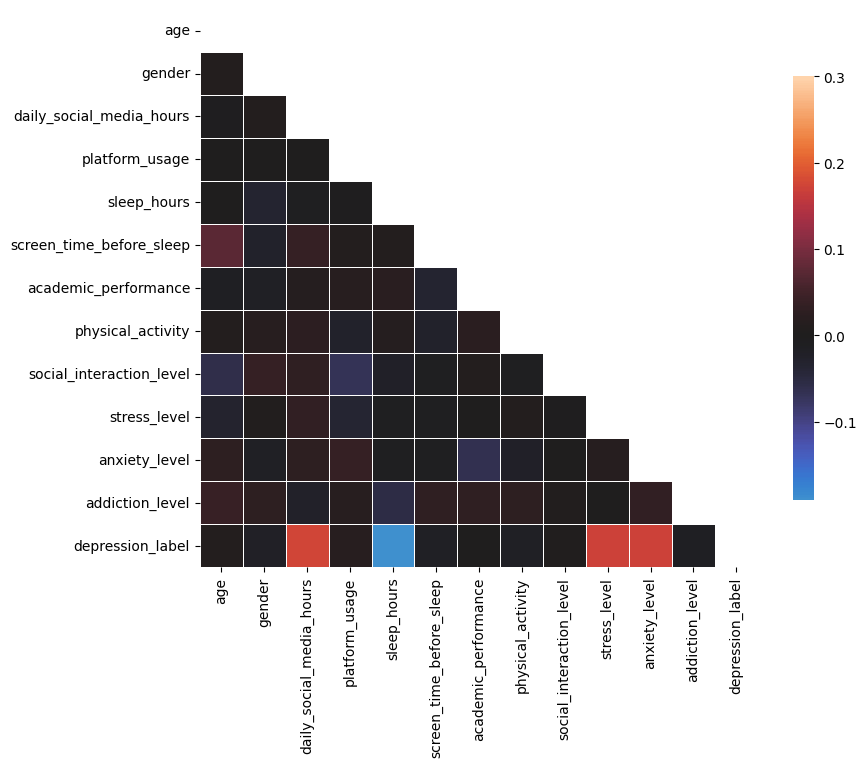

In [11]:
#correlation matrix
import seaborn as sns

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(corr, mask=mask, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


In [197]:
#Let's have a look at our class sampling
oversample = pd.value_counts(df["depression_label"])
print(oversample)
print(f"Percent of our 0 class is: {oversample[0]/df["depression_label"].count()}, and for 1 class id: {oversample[1]/df["depression_label"].count()}")

depression_label
0    1169
1      31
Name: count, dtype: int64
Percent of our 0 class is: 0.9741666666666666, and for 1 class id: 0.025833333333333333


/tmp/ipykernel_22195/1383184722.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  oversample = pd.value_counts(df["depression_label"])


Terrible. 97.4 % oversampling... But it's simillar to real world data, so we have to cast SMOTE to balance our class oversampling. After all data preporation we can get down to our algorithm.

> Добавить блок с цитатой



In [198]:
x_train = df.drop("depression_label", axis=1)
y_train = df["depression_label"]

In [199]:
from imblearn.over_sampling import SMOTE

#Apply SMOTE
smt = SMOTE()
x_train, y_train = smt.fit_resample(x_train, y_train)

In [200]:
#inspect if it's ok)
y_train.value_counts()

,count
depression_label,
0,1169
1,1169


In [202]:
#let's merge our data, we need it because we have to extract average and std of our classes separately
merged = x_train.join(y_train)

In [203]:
#separating
class_1 = merged[merged["depression_label"] == 1]
class_0 = merged[merged["depression_label"] == 0]

In [204]:
#We will evaluate our model with test dataset
class_1_train = class_1[:-100]
class_0_train = class_0[:-100]
class_1_test = class_1[-100:-1]
class_0_test = class_0[-100:-1]

In [236]:
tr_data_len = len(class_1_train) + len(class_0_train)

In [235]:
#calculating prior probabilities for both classes, actually we could avoid this step just because we had already applyed SMOTE which aligned our classses oversampling
prior_1 = np.log(len(class_1_train) / tr_data_len)
prior_0 = np.log(len(class_0_train) / tr_data_len)

Okay, so we've finished with feature managing and we can finally get down to Gaussian Baessian classification algorithm explanation and exploration! Why Gaussian? Let's first consider Naive Baessian algorithm, we are calculating P(Y|x) so conditional probability of class i with given x. Baessian formula: P(Y|x) = P(Y)*p(x|Y)/p(x), where p() is probability density function. The main difficulty is to clculate p(x|Y), and in Naive Baess we tend to think that features aren't related between each other in probability meaning. In this case covarience matrix is diagonal. We can present our covariational matrix as singular decomposition COV = QVQ<sup>-1</sup>, where Q is matrix of eigen vectors of matrix COV and V is diag matrix with eigen values or dispersions of COV. So covariational matrix is defining transformation from uncorrelated data to correlated, and when we take inverted matrix of it, we just move to uncorrelated fatures space, and then apply our Naive Baess!

In [242]:
#function which calculates parametrs for every class features distribution
def calc_params(class_dataset):
  X = class_dataset.drop("depression_label", axis=1).values #we don't need this :)
  mu = np.mean(X, axis=0) #average
  cov = np.cov(X, rowvar=False) #covarience matrix
  dim = X.shape[1] #feature dimension
  return mu, cov, dim

#function which calculates our likelihoods by formula upper
def calc_likelihoods(class_params: dict, x: np.ndarray):
  diff = x - class_params["mu"]
  exponent = -0.5 * diff.T @ np.linalg.inv(class_params["cov"]) @ diff
  coef = 1 / np.sqrt((2*np.pi)**class_params["dim"] * np.linalg.det(class_params["cov"]))
  p = coef * np.exp(exponent)
  return np.log(p)

#predicting probs for our X
def predict(X: np.ndarray, cp1, cp0, priors: np.ndarray):
  probs = []
  for x in X.values:
    likelihood = np.array((calc_likelihoods(cp0, np.array(x)), calc_likelihoods(cp1, np.array(x)))) #log likelihood for every class
    p = likelihood + priors #log(a*b) = log(a) + log(b)
    probs.append(p)
  return probs

#metrics
def evaluate(predicts, y_true):
  y_pred = np.argmax(predicts, axis=1)
  y_true_vals = y_true.values
  accuracy = np.mean(y_pred == y_true_vals)

  TP = np.sum((y_true_vals == 1) & (y_pred == 1))
  TN = np.sum((y_true_vals == 0) & (y_pred == 0))
  FP = np.sum((y_true_vals == 0) & (y_pred == 1))
  FN = np.sum((y_true_vals == 1) & (y_pred == 0))

  confusion_matrix = np.array([
      [TN, FP],
      [FN, TP]
  ])
  precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
  recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

  return accuracy, precision, recall, confusion_matrix

In [244]:
cp1 = calc_params(class_1_train) #get class 1 distribution params
params_class_1 = {"mu": cp1[0], "cov": cp1[1], "dim": cp1[2]}

cp0 = calc_params(class_0_train)#get class 0 distribution params
params_class_0 = {"mu": cp0[0], "cov": cp0[1], "dim": cp0[2]}

In [245]:
#creating one test class from 2 separated and extracting x, y
test_class = pd.concat([class_1_test, class_0_test])
test_class_x = test_class.drop("depression_label", axis=1)
test_class_y = test_class["depression_label"]

In [247]:
#Final step! predictions and evaluation.
predicts = predict(test_class_x, params_class_1, params_class_0, (prior_1, prior_0))
accuracy, precision, recall, conf_matrix = evaluate(predicts, test_class_y)

print(f"Test dataset with size {len(test_class)}")
print("-" * 30)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("-" * 30)
print("Confusion Matrix:")
print(f"TN: {conf_matrix[0,0]:<5} | FP: {conf_matrix[0,1]}")
print(f"FN: {conf_matrix[1,0]:<5} | TP: {conf_matrix[1,1]}")

Test dataset with size 198
------------------------------
Accuracy:  0.9848
Precision: 0.9800
Recall:    0.9899
------------------------------
Confusion Matrix:
TN: 97    | FP: 2
FN: 1     | TP: 98


So, pretty good! Personnaly, for me it's absolutely incredable how ml algorithms are related between each other. You may couldn't even expect that you'll find singular decomposition and part of PCA while working with probabilities, amazing! I hope you've found this tutorial interesting and, maybe learned smth new!
